In [32]:
import osmnx as ox
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import folium
from shapely.geometry import Polygon, LineString
from shapely.ops import linemerge

import os
os.makedirs('data', exist_ok=True)

print(f"OSMnx version: {ox.__version__}")
print(f"NetworkX version: {nx.__version__}")

OSMnx version: 2.1.0
NetworkX version: 3.6.1


# Etapa 1 – Construção do grafo com OSMnx

Esta etapa tem como objetivo realizar a extração dos dados viários utilizando a biblioteca `OSMnx` e preparar o grafo para análise.

## Visualização da Área de Estudo

Antes de extrair os dados, vamos visualizar a área delimitada pelo polígono no mapa interativo.

In [2]:
# Coordenadas fornecidas (Latitude, Longitude)
coords = [
    (-5.918514, -35.277890),
    (-5.973278, -35.273041),
    (-5.973449, -35.188755),
    (-5.959791, -35.130390),
    (-5.874716, -35.167426),
    (-5.838087, -35.213432),
    (-5.883595, -35.265617)
]


# Criando o mapa centralizado na média das coordenadas
center_lat = sum(c[0] for c in coords) / len(coords)
center_lon = sum(c[1] for c in coords) / len(coords)
m = folium.Map(location=[center_lat, center_lon], zoom_start=13, tiles="OpenStreetMap")

# Adicionando o polígono ao mapa
folium.Polygon(
    locations=coords,
    color="blue",
    weight=2,
    fill=True,
    fill_color="blue",
    fill_opacity=0.2,
    popup="Área de Estudo BR-101"
).add_to(m)

m

## Extração da Rede Viária

Agora que confirmamos a área, realizamos a extração do grafo utilizando o `OSMnx`.

In [3]:
# Invertendo para (Longitude, Latitude) para o Shapely/OSMnx
polygon_coords = [(lon, lat) for lat, lon in coords]
boundary_polygon = Polygon(polygon_coords)

# Extraindo o grafo da rede viária dentro do polígono
H = ox.graph_from_polygon(boundary_polygon, network_type="drive")

print(f"Grafo completo extraído com {len(H.nodes)} nós e {len(H.edges)} arestas.")

Grafo completo extraído com 8599 nós e 22131 arestas.


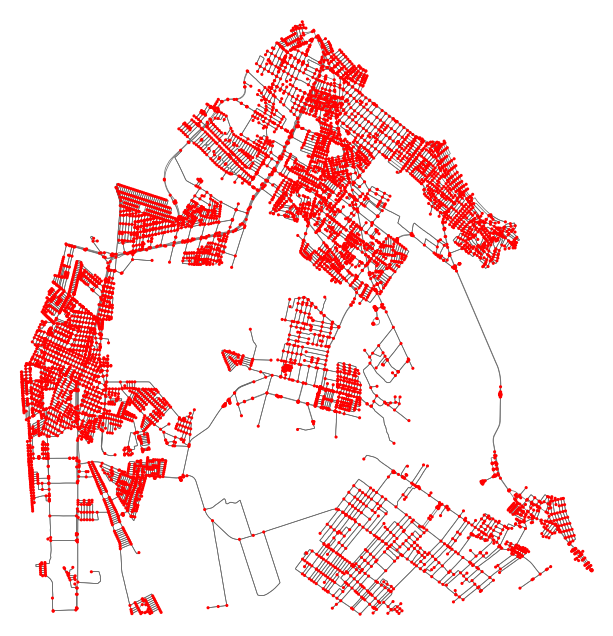

In [4]:
# Visualizando o grafo extraído de forma estática
fig, ax = ox.plot_graph(H, node_size=5, node_color="r", edge_color="#666666", edge_linewidth=0.5, bgcolor="w")
plt.show()

## Agrupando nós por nome da rua (aresta com mesmo nome)

In [5]:
G = nx.MultiDiGraph()

# -------------------------
# Auxiliary graph
# -------------------------
street_graph = nx.Graph()

for u, v, key, data in H.edges(keys=True, data=True):
    name = data.get("name")
    if name is None:
        continue

    if isinstance(name, list):
        name = " | ".join(sorted(map(str, name)))
    else:
        name = str(name)

    geom = data.get("geometry")
    if geom is None:
        geom = LineString([
            (H.nodes[u]["x"], H.nodes[u]["y"]),
            (H.nodes[v]["x"], H.nodes[v]["y"])
        ])

    street_graph.add_edge(
        u,
        v,
        name=name,
        geometry=geom
    )

# -------------------------
# Collapse same-name connected components
# -------------------------
visited = set()
node_lookup = {}
component_id = 0

for u, v, data in street_graph.edges(data=True):
    eid = frozenset((u, v))
    if eid in visited:
        continue

    street_name = data["name"]

    same_edges = [
        (a, b, d)
        for a, b, d in street_graph.edges(data=True)
        if d["name"] == street_name
    ]

    S = nx.Graph()
    S.add_edges_from(
        (a, b, {"geometry": d["geometry"]})
        for a, b, d in same_edges
    )

    for comp in nx.connected_components(S):
        sub = S.subgraph(comp)
        edges = list(sub.edges(data=True))

        if not edges:
            continue

        first_edge = frozenset((edges[0][0], edges[0][1]))
        if first_edge in visited:
            continue

        component_id += 1
        collapsed_id = component_id
        geom_parts = []

        for a, b, d in edges:
            visited.add(frozenset((a, b)))
            geom_parts.append(d["geometry"])

        merged_geom = linemerge(geom_parts)
        centroid = merged_geom.centroid

        G.add_node(
            collapsed_id,
            street_name=str(street_name),
            geometry=merged_geom,
            original_nodes=",".join(map(str, comp)),
            x=float(centroid.x),
            y=float(centroid.y),
        )

        for n in comp:
            node_lookup.setdefault(n, set()).add(collapsed_id)

# -------------------------
# Add intersections between collapsed streets
# -------------------------
edge_id = 0

for original_node, collapsed_nodes in node_lookup.items():
    collapsed_nodes = list(collapsed_nodes)

    for i in range(len(collapsed_nodes)):
        for j in range(i + 1, len(collapsed_nodes)):
            a = collapsed_nodes[i]
            b = collapsed_nodes[j]

            if a == b:
                continue

            if G.has_edge(a, b):
                continue

            edge_id += 1

            # geometry between centroids (for plotting)
            line = LineString([
                (G.nodes[a]["x"], G.nodes[a]["y"]),
                (G.nodes[b]["x"], G.nodes[b]["y"])
            ])

            G.add_edge(
                a,
                b,
                key=edge_id,
                geometry=line,
                length=line.length
            )

# -------------------------
# Required OSMnx metadata
# -------------------------
G.graph["crs"] = H.graph["crs"]

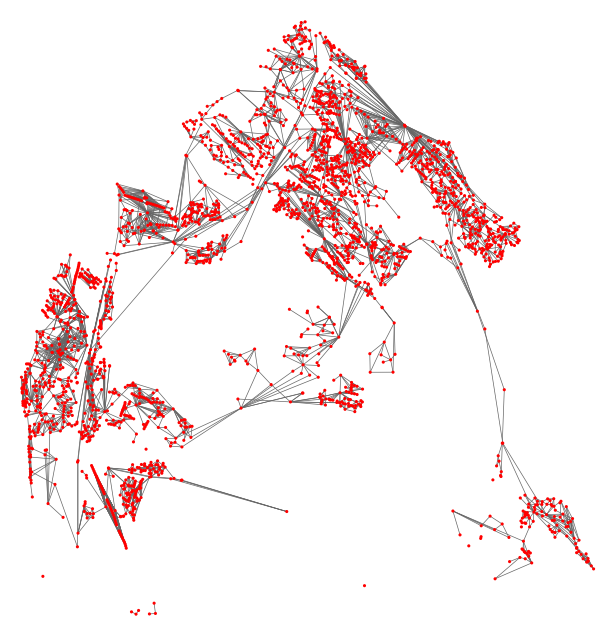

In [6]:
# Visualizando o grafo extraído de forma estática
fig, ax = ox.plot_graph(G, node_size=5, node_color="r", edge_color="#666666", edge_linewidth=0.5, bgcolor="w")
plt.show()

## Preparação do Grafo

Conforme o roteiro e para simplificar a análise, precisamos converter o grafo para não-direcionado para permitir cálculos como o k-core.

In [7]:
# Convertendo para não-direcionado
G_undirected = G.to_undirected()
print(f"Grafo convertido para não-direcionado.")
print(f"Nós: {len(G_undirected.nodes)}, Arestas: {len(G_undirected.edges)}")

Grafo convertido para não-direcionado.
Nós: 2642, Arestas: 5656


# Etapa 2 – Análise estrutural com NetworkX

Nesta etapa, calculamos as métricas de centralidade e a decomposição K-Core para identificar os nós mais importantes e as regiões mais densamente conectadas.

In [8]:
# 1. Grau (Degree)
degree_dict = dict(G_undirected.degree())
nx.set_node_attributes(G_undirected, degree_dict, 'degree')

print(f'Maior grau: {max(degree_dict.values())}')
print(f'Grau médio: {sum(degree_dict.values())/len(G_undirected):.2f}')

Maior grau: 49
Grau médio: 4.28


Text(0, 0.5, '# nós')

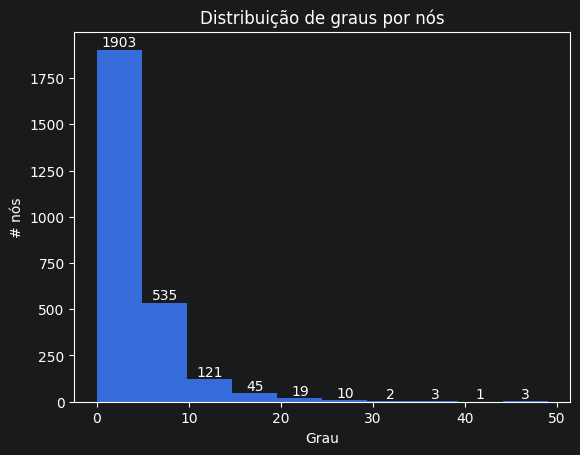

In [9]:
counts, bins, patches = plt.hist(degree_dict.values()) #, max(degree_dict.values()))

# Add labels on top of bars
plt.bar_label(patches, fmt='%.0f')

plt.title('Distribuição de graus por nós')
plt.xlabel('Grau')
plt.ylabel('# nós')

In [10]:
top_degree = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
print('Top 10 ruas por grau: ', {G_undirected.nodes[item[0]]["street_name"]: item[1] for item in top_degree})

Top 10 ruas por grau:  {'Avenida Maria Amélia Machado': 49, 'Rua Campo Alegre': 45, 'Rua Campo Azul': 45, 'Avenida Maria Lacerda Montenegro': 41, 'Avenida Engenheiro Roberto Freire': 38, 'Rua Gilberto Roberto Gomes': 36, 'Avenida Ayrton Senna': 35, 'Avenida Abel Cabral': 34, 'Avenida Aeroporto Augusto Severo': 31, 'Rua Brigadeiro Eduardo Gomes': 28}


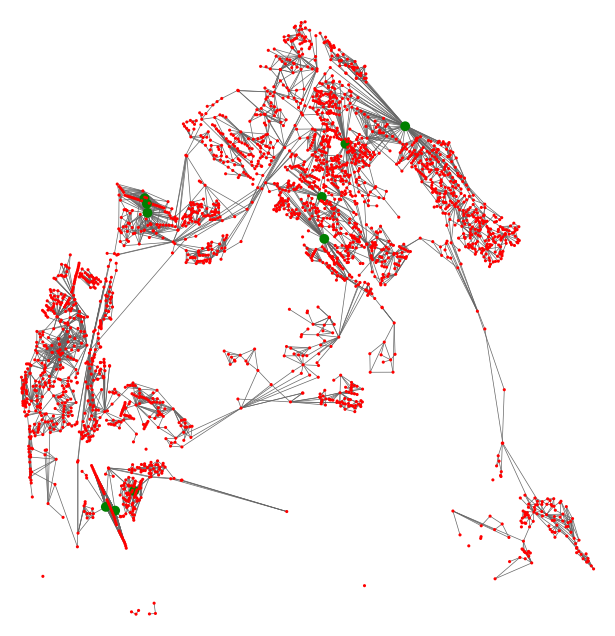

In [11]:
selected = {node[0] for node in top_degree}
node_colors = [
    "g" if node in selected else "r"
    for node in G.nodes()
]

node_sizes = [
    50 if node in selected else 5
    for node in G.nodes()
]

fig, ax = ox.plot_graph(G, node_size=node_sizes, node_color=node_colors, edge_color="#666666", edge_linewidth=0.5, bgcolor="w")
plt.show()

In [12]:
# 2. Centralidade de Intermediação (Betweenness Centrality)
# Esta métrica pode ser lenta. Para ~8.6k nós, pode levar alguns minutos.
print("Calculando Betweenness Centrality... (isso pode levar um momento)")
betweenness = nx.betweenness_centrality(G_undirected, normalized=True)
nx.set_node_attributes(G_undirected, betweenness, 'betweenness')

print('Centralidade de Intermediação calculada.')

Calculando Betweenness Centrality... (isso pode levar um momento)
Centralidade de Intermediação calculada.


Text(0, 0.5, '# nós')

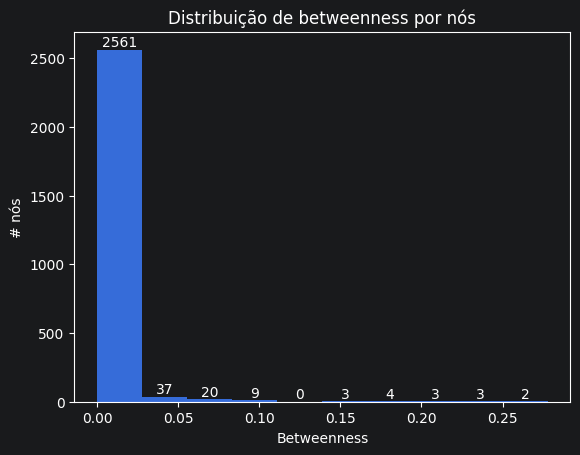

In [13]:
counts, bins, patches = plt.hist(betweenness.values())

# Add labels on top of bars
plt.bar_label(patches, fmt='%.0f')

plt.title('Distribuição de betweenness por nós')
plt.xlabel('Betweenness')
plt.ylabel('# nós')

In [14]:
top_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
print('Top 10 ruas por betweenness: ', {G_undirected.nodes[item[0]]["street_name"]: item[1] for item in top_betweenness})

Top 10 ruas por betweenness:  {'Avenida Maria Lacerda Montenegro': 0.27795744644293346, 'Avenida Gandhi': 0.2580647036842218, 'Avenida Olavo Lacerda Montenegro': 0.2330797185505564, "Avenida Pedra d'Água": 0.227990751374542, 'Avenida Dão Silveira': 0.21675581506862385, 'Avenida Ayrton Senna': 0.2074374739721253, 'Avenida das Alagoas': 0.20736985185439333, 'Avenida Senador Salgado Filho': 0.1902527794577982, 'Estrada de Cajupiranga': 0.18839274728734276}


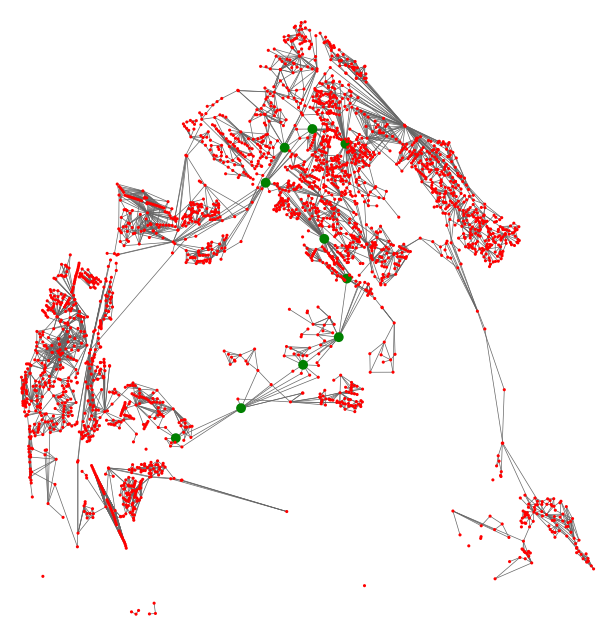

In [15]:
selected = {node[0] for node in top_betweenness}
node_colors = [
    "g" if node in selected else "r"
    for node in G.nodes()
]

node_sizes = [
    50 if node in selected else 5
    for node in G.nodes()
]

fig, ax = ox.plot_graph(G, node_size=node_sizes, node_color=node_colors, edge_color="#666666", edge_linewidth=0.5, bgcolor="w")
plt.show()

In [16]:
# 3. Centralidade de Proximidade (Closeness Centrality)
print("Calculando Closeness Centrality... (isso pode levar um momento)")
closeness = nx.closeness_centrality(G_undirected)
nx.set_node_attributes(G_undirected, closeness, 'closeness')

print('Centralidade de Proximidade calculada.')

Calculando Closeness Centrality... (isso pode levar um momento)
Centralidade de Proximidade calculada.


Text(0, 0.5, '# nós')

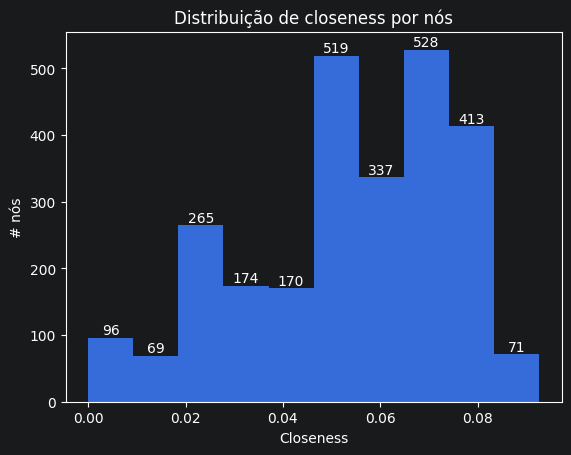

In [17]:
counts, bins, patches = plt.hist(closeness.values())

# Add labels on top of bars
plt.bar_label(patches, fmt='%.0f')

plt.title('Distribuição de closeness por nós')
plt.xlabel('Closeness')
plt.ylabel('# nós')

In [18]:
top_closeness = sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:10]
print('Top 10 ruas por grau: ', {G_undirected.nodes[item[0]]["street_name"]: item[1] for item in top_closeness})

Top 10 ruas por grau:  {'Avenida Senador Salgado Filho': 0.09263746022904179, 'Avenida São Miguel dos Caribés': 0.09162962262402315, 'Avenida das Alagoas': 0.09055365668427715, 'Avenida Senador Salgado Filho | Avenida das Alagoas': 0.090486407211544, 'Avenida Abel Cabral': 0.09011164840049135, 'Rua Pintassilgos': 0.09008943919055384, 'Rua Governador Valadares': 0.08952458745328266, 'Avenida Ayrton Senna': 0.08937573733966285, 'Rua Arapiraca': 0.08928404752607551, 'Rua Mata Grande': 0.0891968986265869}


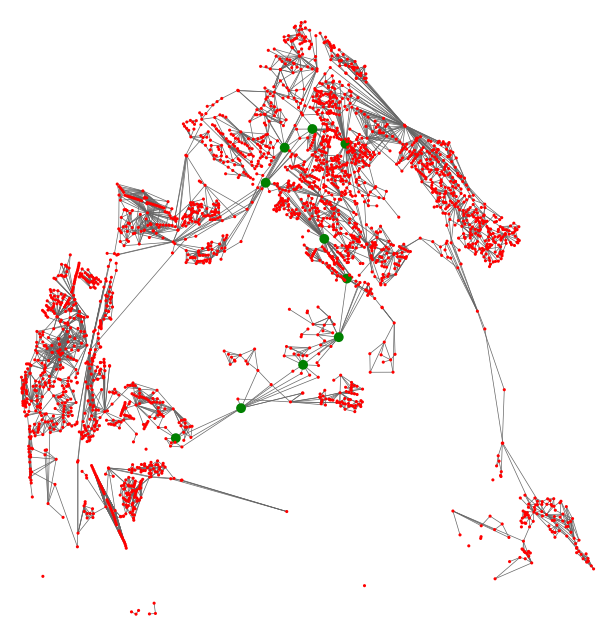

In [19]:
selected = {node[0] for node in top_betweenness}
node_colors = [
    "g" if node in selected else "r"
    for node in G.nodes()
]

node_sizes = [
    50 if node in selected else 5
    for node in G.nodes()
]

fig, ax = ox.plot_graph(G, node_size=node_sizes, node_color=node_colors, edge_color="#666666", edge_linewidth=0.5, bgcolor="w")
plt.show()

In [20]:
# 4. Decomposição K-Core
# Primeiro removemos self-loops pois o core_number não os suporta
G_tmp = nx.Graph(G_undirected)
G_tmp.remove_edges_from(nx.selfloop_edges(G_tmp))

kcore = nx.core_number(G_tmp)
nx.set_node_attributes(G_undirected, kcore, 'kcore')

print(f'Maior K-Core encontrado: {max(kcore.values())}')

Maior K-Core encontrado: 8


Text(0, 0.5, '# nós')

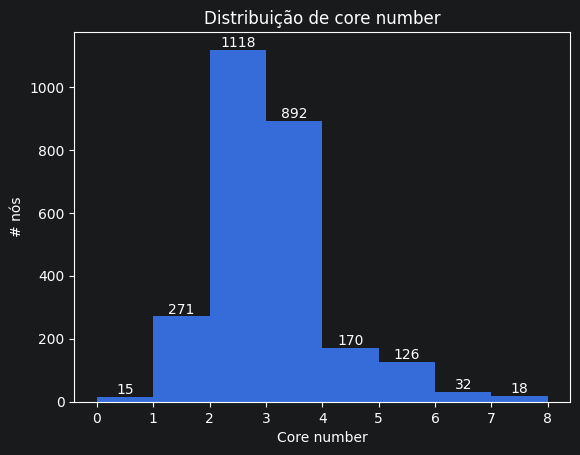

In [21]:
counts, bins, patches = plt.hist(kcore.values(), 8)

# Add labels on top of bars
plt.bar_label(patches, fmt='%.0f')

plt.title('Distribuição de core number')
plt.xlabel('Core number')
plt.ylabel('# nós')

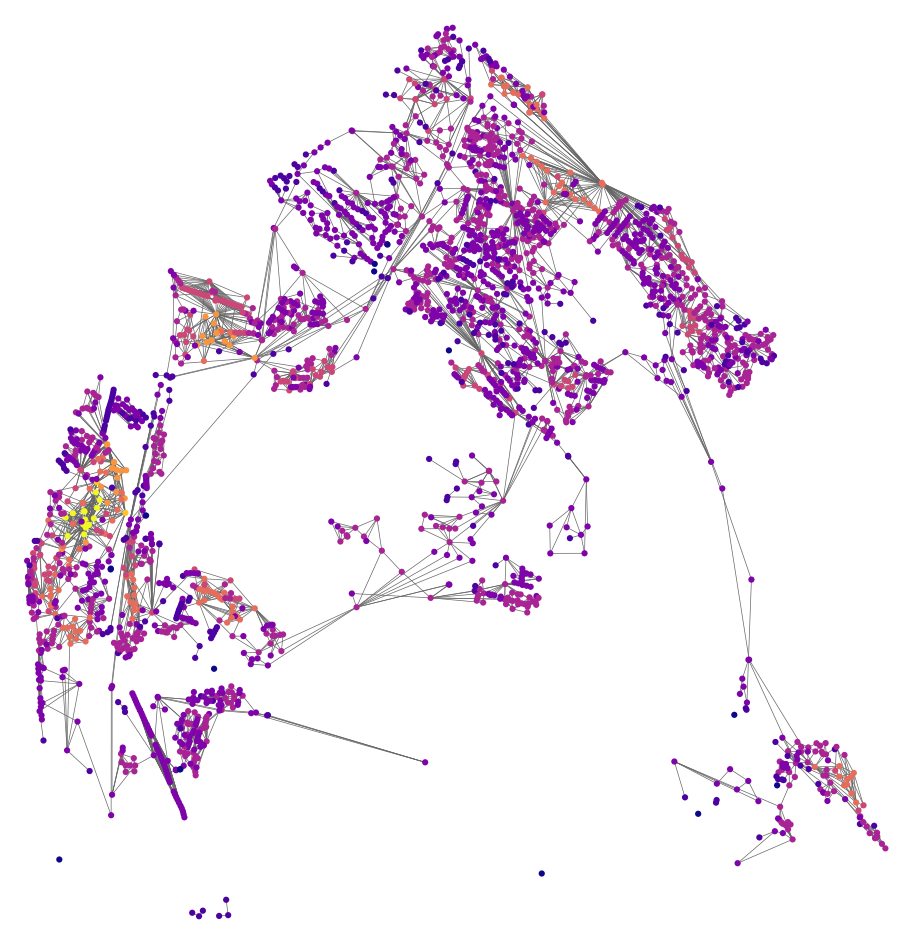

In [34]:
cmap = matplotlib.colormaps['plasma'](np.linspace(0, 1, 9))
node_colors = [
    cmap[kcore[node]]
    for node in G.nodes()
]

fig, ax = ox.plot_graph(G, figsize=(12,12), node_size=20, node_color=node_colors, edge_color="#666666", edge_linewidth=0.5,
                        bgcolor="w")
plt.show()

## Exportação dos Dados

Salvamos o grafo processado com as métricas para visualização externa (ex: Gephi).

In [23]:
import networkx as nx

# 1. Cria uma cópia para preservar o grafo original intacto
G_to_save = G_undirected.copy()

# 2. Limpa os atributos das ARESTAS (edges)
for u, v, data in G_to_save.edges(data=True):
    for key, value in list(data.items()):
        # Se for geometria (Shapely), converte para WKT
        if key == "geometry" and hasattr(value, "wkt"):
            data[key] = value.wkt
        # Se for uma lista, transforma em string separada por vírgula (ex: ['A', 'B'] -> "A, B")
        elif isinstance(value, list):
            data[key] = ", ".join(map(str, value))

# 3. Limpa os atributos dos NÓS (nodes) - por segurança, caso haja listas lá também
for n, data in G_to_save.nodes(data=True):
    for key, value in list(data.items()):
        if key == "geometry" and hasattr(value, "wkt"):
            data[key] = value.wkt
        elif isinstance(value, list):
            data[key] = ", ".join(map(str, value))

# 4. Salva o arquivo limpo
nx.write_graphml(G_to_save, "data/br101_colapsados_analise.graphml")
print("Grafo exportado com sucesso para data/br101_colapsados_analise.graphml")

Grafo exportado com sucesso para data/br101_colapsados_analise.graphml
